1. import libraries

In [126]:
import os 
print(os.getcwd())

d:\GIT\linear regression


In [101]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

In [102]:
plt.style.use('default')

In [103]:
df = pd.read_csv('./E-commerce Customer Behavior.csv')

In [104]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df
print("\nDataset Info:")
df.info()
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (350, 11)

First 5 rows:

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        350 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB

Basic Statistics:


,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [105]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64


In [106]:
df["Satisfaction Level"].fillna(df["Satisfaction Level"].mode()[0], inplace=True)

C:\Users\kairo\AppData\Local\Temp\ipykernel_15984\4230081484.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Satisfaction Level"].fillna(df["Satisfaction Level"].mode()[0], inplace=True)


In [107]:
df = pd.get_dummies(df, drop_first=True)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Customer ID                     350 non-null    int64  
 1   Age                             350 non-null    int64  
 2   Total Spend                     350 non-null    float64
 3   Items Purchased                 350 non-null    int64  
 4   Average Rating                  350 non-null    float64
 5   Discount Applied                350 non-null    bool   
 6   Days Since Last Purchase        350 non-null    int64  
 7   Gender_Male                     350 non-null    bool   
 8   City_Houston                    350 non-null    bool   
 9   City_Los Angeles                350 non-null    bool   
 10  City_Miami                      350 non-null    bool   
 11  City_New York                   350 non-null    bool   
 12  City_San Francisco              350 

In [109]:
df_corr = df.copy()
df_corr.drop("Customer ID", axis=1, inplace=True)

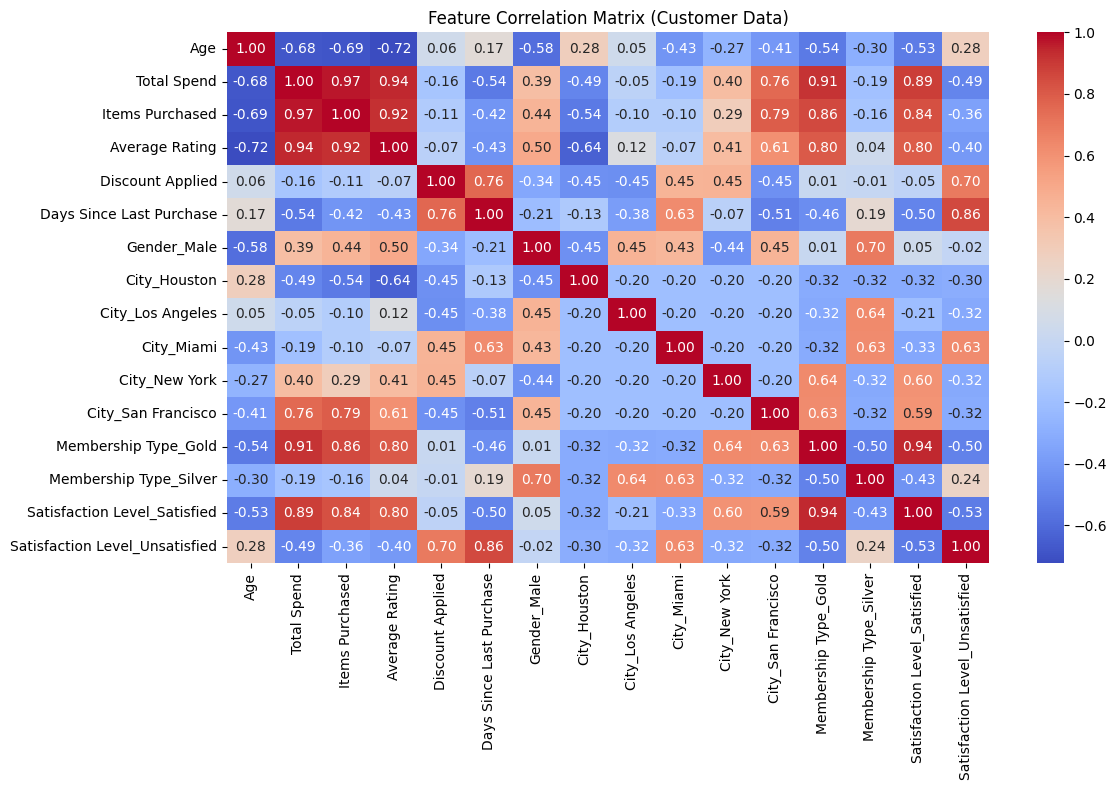

In [110]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_corr.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix (Customer Data)")
plt.tight_layout()
plt.show()

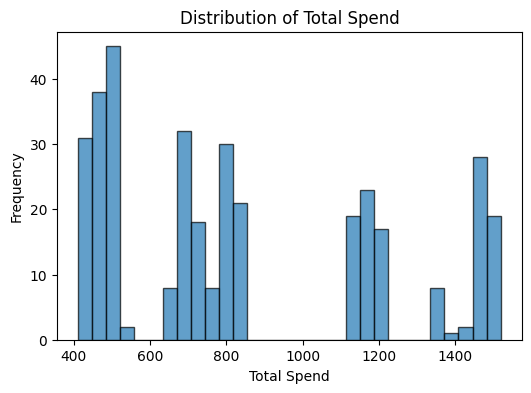

In [111]:
plt.figure(figsize=(6, 4))

plt.hist(df["Total Spend"], bins=30, edgecolor="black", alpha=0.7)

plt.title("Distribution of Total Spend")
plt.xlabel("Total Spend")
plt.ylabel("Frequency")

plt.show()

In [112]:
most_correlated = correlation_matrix["Total Spend"].abs().sort_values(ascending=False).index[1]

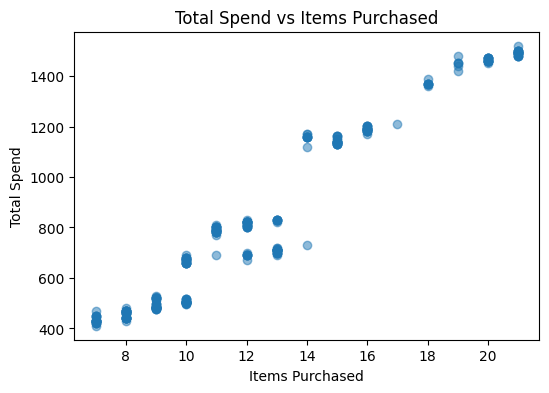

In [113]:
plt.figure(figsize=(6, 4))
plt.scatter(df_corr[most_correlated], df_corr["Total Spend"], alpha=0.5)
plt.title(f"Total Spend vs {most_correlated}")
plt.xlabel(most_correlated)
plt.ylabel("Total Spend")

plt.show()

In [114]:
target = "Total Spend"

In [115]:
correlation_matrix = df.corr(numeric_only=True)

most_correlated = correlation_matrix[target].abs().sort_values(ascending=False).index[1]

In [116]:
print("="*60)
print("NUMERICAL INSIGHTS FROM VISUALIZATIONS")
print("="*60)


print("\nTOTAL SPEND DISTRIBUTION INSIGHTS:")
print(f"Mean Spend: {df[target].mean():,.2f}")
print(f"Median Spend: {df[target].median():,.2f}")
print(f"Mode Spend (approx): {df[target].mode()[0]:,.2f}")
print(f"Std Dev: {df[target].std():,.2f}")
print(f"Skewness: {df[target].skew():.3f} (0=normal, >0=right-skewed)")
print(f"Spend Range: {df[target].min():,.2f} - {df[target].max():,.2f}")

NUMERICAL INSIGHTS FROM VISUALIZATIONS

TOTAL SPEND DISTRIBUTION INSIGHTS:
Mean Spend: 845.38
Median Spend: 775.20
Mode Spend (approx): 710.40
Std Dev: 362.06
Skewness: 0.563 (0=normal, >0=right-skewed)
Spend Range: 410.80 - 1,520.10


In [117]:
y = df['Total Spend']

X = df.drop(['Total Spend', 'Customer ID'], axis=1)

In [118]:

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 280 samples
Test set size: 70 samples


In [119]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [120]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Model Coefficients (Feature Importance):")
print(coefficients)

print(f"\nIntercept: {model.intercept_:.4f}")

Model Coefficients (Feature Importance):
                           Feature  Coefficient
11            Membership Type_Gold   140.177998
1                  Items Purchased   100.839081
10              City_San Francisco    97.820878
9                    City_New York    80.977319
3                 Discount Applied   -48.484276
6                     City_Houston   -45.606393
12          Membership Type_Silver    33.681087
8                       City_Miami    27.110767
4         Days Since Last Purchase   -17.492091
7                 City_Los Angeles    15.687138
0                              Age     7.030793
5                      Gender_Male     5.877489
13    Satisfaction Level_Satisfied    -5.298696
2                   Average Rating     2.672836
14  Satisfaction Level_Unsatisfied    -1.752409

Intercept: 830.6375


In [121]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [122]:
comparison_df = pd.DataFrame({
    'Actual_Spend': y_test.values,
    'Predicted_Spend': y_test_pred,
    'Difference': (y_test_pred - y_test.values),
    'Absolute_Error': abs(y_test_pred - y_test.values)
})

comparison_df['Percentage_Error'] = abs(
    (comparison_df['Difference'] / comparison_df['Actual_Spend']) * 100
)

pd.options.display.float_format = '${:,.2f}'.format

print("All Test Set Predictions:")
print(comparison_df.head(20))

pd.reset_option('display.float_format')

All Test Set Predictions:
    Actual_Spend  Predicted_Spend  Difference  Absolute_Error  \
0        $810.90          $820.02       $9.12           $9.12   
1      $1,140.60        $1,144.90       $4.30           $4.30   
2        $710.40          $700.93      $-9.47           $9.47   
3        $830.75          $828.84      $-1.91           $1.91   
4        $430.80          $434.47       $3.67           $3.67   
5        $470.50          $457.05     $-13.45          $13.45   
6        $430.80          $426.64      $-4.16           $4.16   
7      $1,140.60        $1,156.64      $16.04          $16.04   
8      $1,450.50        $1,434.93     $-15.57          $15.57   
9        $430.80          $434.47       $3.67           $3.67   
10     $1,490.10        $1,486.47      $-3.63           $3.63   
11       $690.60          $692.34       $1.74           $1.74   
12     $1,160.30        $1,139.58     $-20.72          $20.72   
13     $1,160.30        $1,139.58     $-20.72          $20.72   

In [123]:
detailed_predictions = X_test.copy()

detailed_predictions['Actual_Spend'] = y_test.values
detailed_predictions['Predicted_Spend'] = y_test_pred
detailed_predictions['Difference'] = y_test_pred - y_test.values
detailed_predictions['Percent_Error'] = abs(
    (detailed_predictions['Difference'] / detailed_predictions['Actual_Spend']) * 100
)

print("\nDetailed Predictions with Features:")
print(
    detailed_predictions[
        list(X_test.columns) +
        ['Actual_Spend', 'Predicted_Spend', 'Difference', 'Percent_Error']
    ].head(10)
)


Detailed Predictions with Features:
     Age  Items Purchased  Average Rating  Discount Applied  \
157   35               12             4.3             False   
341   31               15             4.5              True   
315   27               13             4.1              True   
234   33               13             4.2             False   
155   37                7             3.4             False   
274   36                8             3.0             False   
304   37                7             3.4             False   
227   31               15             4.5              True   
278   30               19             4.6             False   
185   37                7             3.4             False   

     Days Since Last Purchase  Gender_Male  City_Houston  City_Los Angeles  \
157                        13         True         False              True   
341                        36        False         False             False   
315                        61      

In [124]:
def evaluate_model(y_true, y_pred, dataset_name):
    """Calculate and print evaluation metrics"""

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Performance:")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }


train_metrics = evaluate_model(y_train, y_train_pred, "Training")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")


Training Performance:
MSE:  193.3068
RMSE: 13.9035
MAE:  10.5880
R²:   0.9985

Test Performance:
MSE:  258.9506
RMSE: 16.0919
MAE:  11.3702
R²:   0.9981


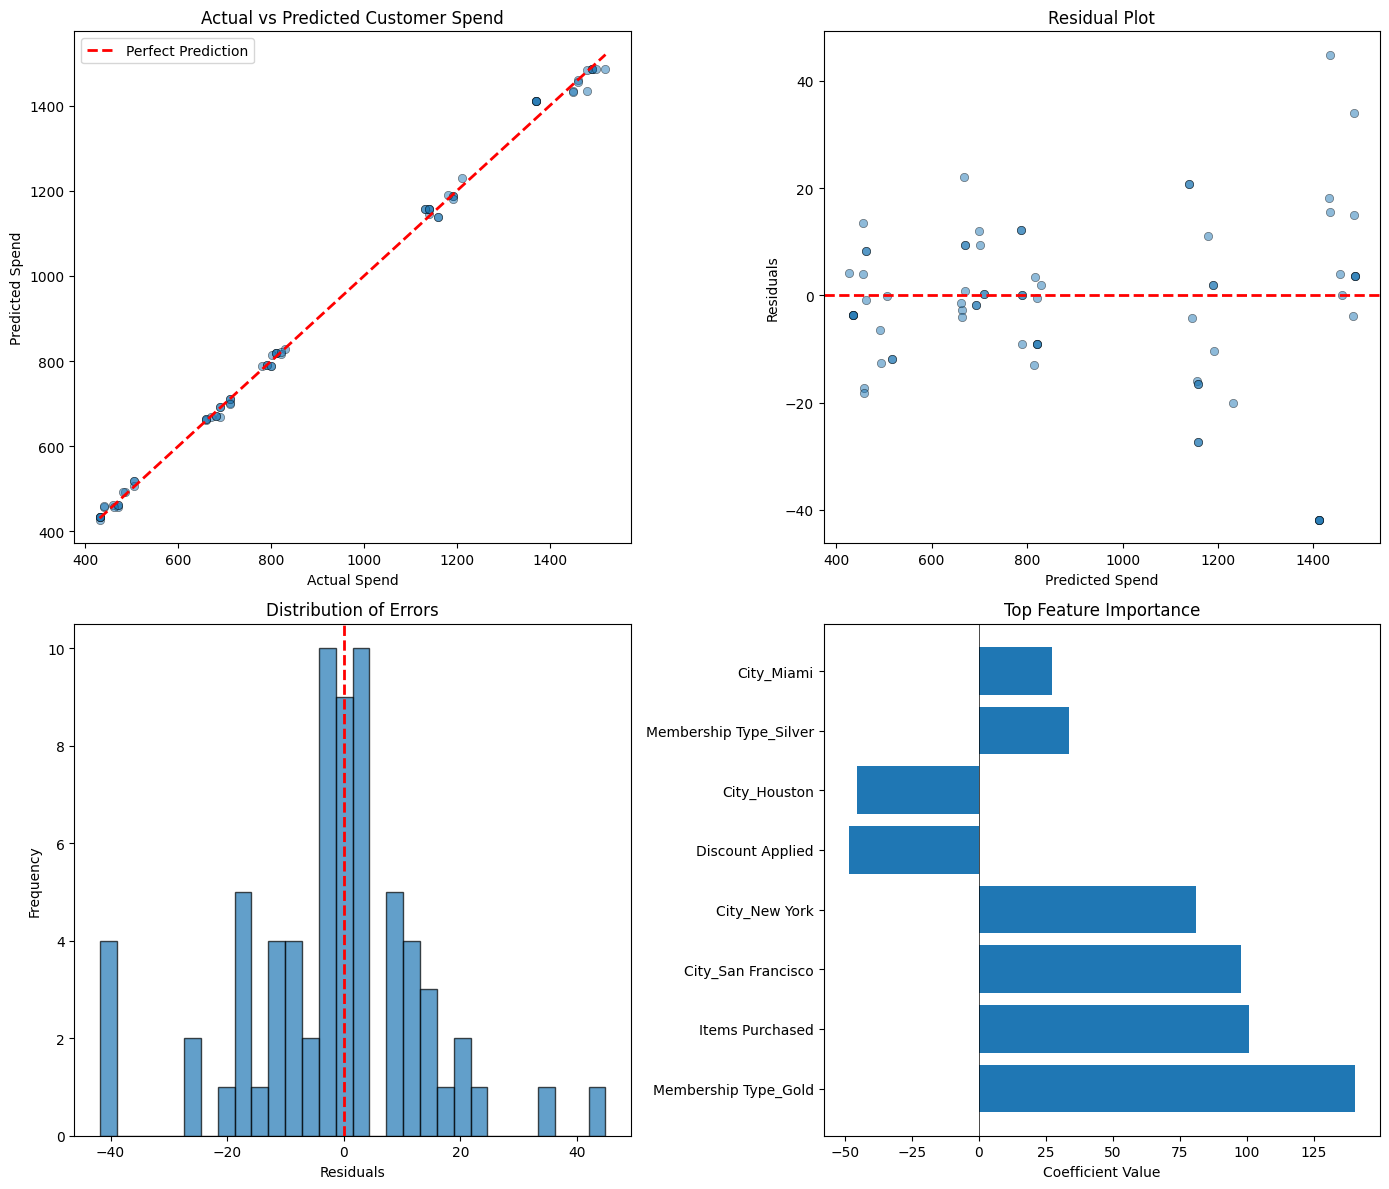

In [125]:

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')

axes[0, 0].set_xlabel('Actual Spend')
axes[0, 0].set_ylabel('Predicted Spend')
axes[0, 0].set_title('Actual vs Predicted Customer Spend')
axes[0, 0].legend()

residuals = y_test - y_test_pred

axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)

axes[0, 1].set_xlabel('Predicted Spend')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')

axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Errors')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)

coeff_plot = coefficients.head(8)

axes[1, 1].barh(coeff_plot['Feature'], coeff_plot['Coefficient'])
axes[1, 1].set_xlabel('Coefficient Value')
axes[1, 1].set_title('Top Feature Importance')
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()